<a href="https://colab.research.google.com/github/Sanmarquino/Modelos-Supervisado-y-No-Supervisados/blob/main/Machine_Learning_Modelos_Lineales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regresión Lineal**

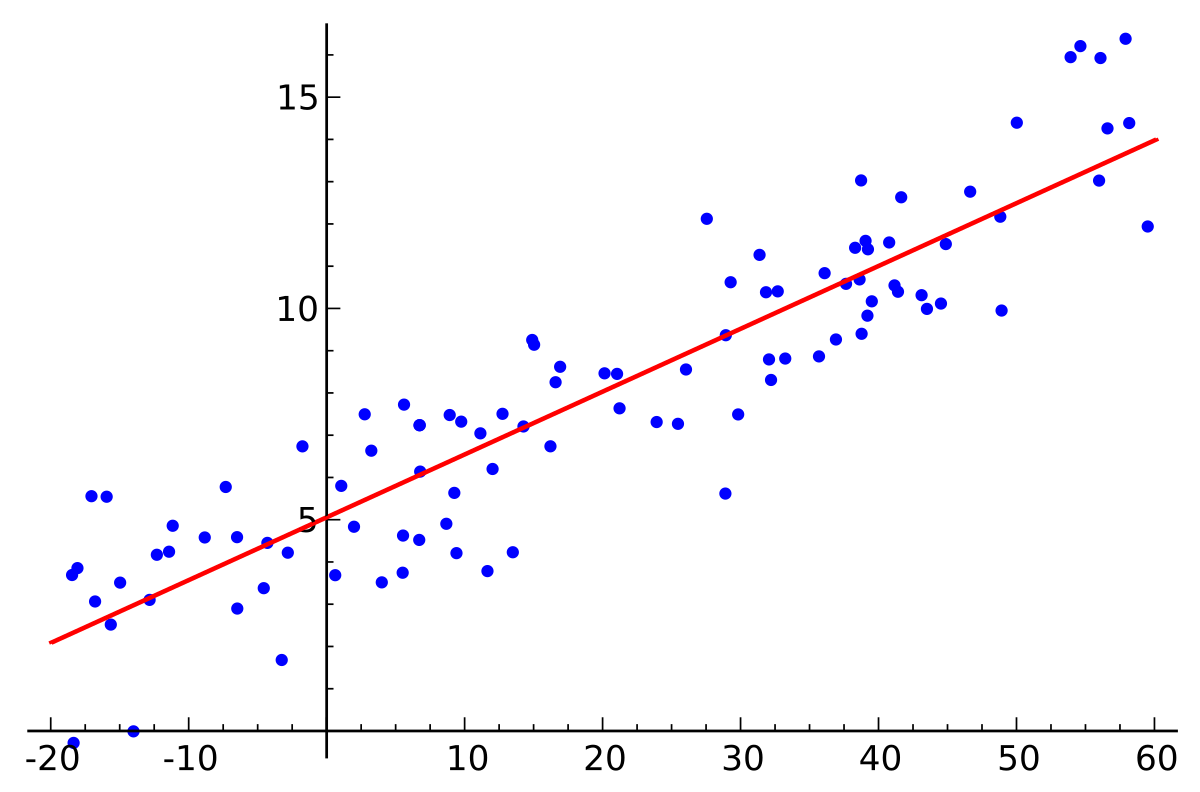

# **Introducción**

La **regresión lineal** es un método estadístico que modela la relación entre una variable continua y una o más variables independientes mediante el ajuste de una ecuación lineal. Sin embargo, al utilizar modelos ajustados por mínimos cuadrados ordinarios (**OLS**), pueden surgir algunas limitaciones en la práctica:

### **Principales limitaciones de OLS**
- **Sensibilidad a predictores correlacionados:** La presencia de colinealidad puede afectar la estabilidad de los coeficientes.
- **Falta de selección de predictores:** Todos los predictores se incorporan en el modelo, incluso si no aportan información relevante, lo que puede complicar la interpretación y reducir la capacidad predictiva.
- **Imposibilidad de ajuste cuando \( p > n \):** Cuando el número de predictores supera el número de observaciones, OLS no puede ajustarse correctamente.

### **Regularización como solución**
Para mitigar estos problemas, se emplean estrategias de **regularización** como **Ridge, Lasso y Elastic Net**. Estas técnicas:
- **Fuerzan a que los coeficientes tiendan a cero**, reduciendo la varianza y el riesgo de sobreajuste (**overfitting**).
- **Atenúan el efecto de la colinealidad** entre predictores.
- **Reducen la influencia de predictores poco relevantes**, mejorando la interpretabilidad del modelo y su generalización.



# **Regularización**

Las estrategias de **regularización** incorporan penalizaciones en el ajuste por **mínimos cuadrados ordinarios (OLS)** con el objetivo de:
- **Evitar el sobreajuste (overfitting)**.
- **Reducir la varianza** en los coeficientes.
- **Atenuar el efecto de la colinealidad** entre predictores.
- **Minimizar la influencia de predictores menos relevantes**.

Al aplicar regularización, se suelen obtener modelos con **mayor capacidad de generalización**, mejorando su desempeño en datos nuevos.

### **Importancia de la Escalación de Datos**
Dado que los métodos de regularización actúan sobre la **magnitud de los coeficientes**, es fundamental que todos los predictores estén en la misma escala. Por esta razón, **es necesario estandarizar o normalizar los datos antes de entrenar el modelo**.

# **Regresión Ridge**

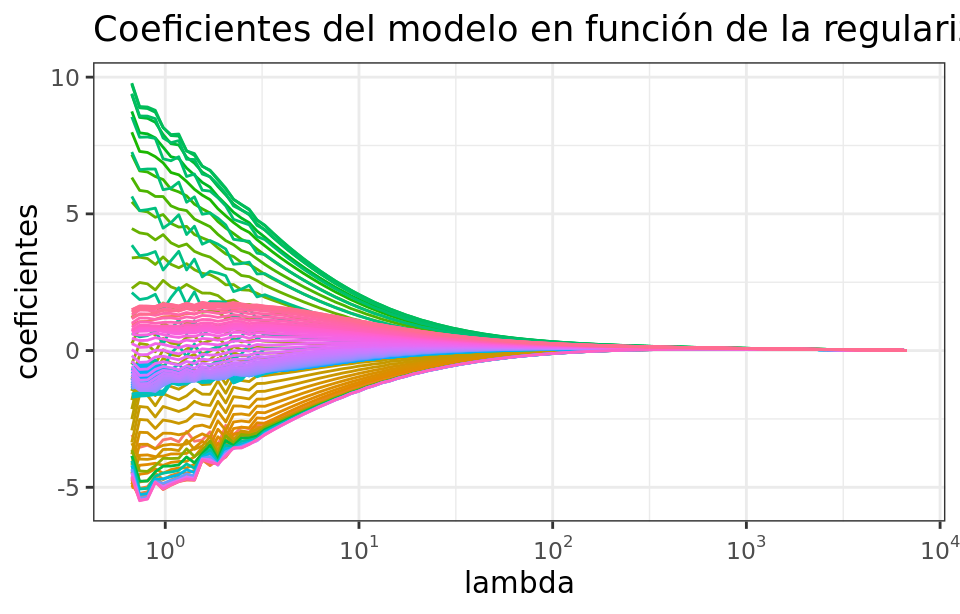

La regularización **Ridge** penaliza la suma de los coeficientes elevados al cuadrado:

$$
||\beta||^2_2 = \sum_{j=1}^{p} \beta_j^2
$$

A esta penalización se le conoce como **L2** y tiene el efecto de **reducir de forma proporcional el valor de todos los coeficientes del modelo sin que estos lleguen a cero**.

El grado de penalización está controlado por el hiperparámetro $\lambda$:
- Cuando $\lambda = 0$, la penalización es nula y el resultado es equivalente a un modelo de mínimos cuadrados ordinarios (OLS).
- A medida que $\lambda$ aumenta, la penalización se incrementa, reduciendo el valor de los coeficientes de los predictores.

La función de costo de la regresión Ridge es:

$$
\sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2
$$

$$
= \text{suma de residuos al cuadrado} + \lambda \sum_{j=1}^{p} \beta_j^2
$$

## **Ventajas de Ridge**
La principal ventaja de aplicar **Ridge** en lugar del ajuste por mínimos cuadrados ordinarios (OLS) es la **reducción de la varianza**.
- En situaciones donde la relación entre la variable respuesta y los predictores es aproximadamente lineal, las estimaciones por OLS tienen **bajo sesgo** pero **alta varianza**, lo que puede hacer que pequeños cambios en los datos de entrenamiento generen grandes variaciones en el modelo.
- Este problema es más evidente cuando el número de predictores se acerca al número de observaciones ($p \approx n$), e incluso, cuando $p > n$, OLS no es factible.
- Un **valor adecuado de $\lambda$** en Ridge puede reducir la varianza sin aumentar demasiado el sesgo, logrando un **menor error total**.

## **Desventajas de Ridge**
- La regresión **Ridge nunca lleva los coeficientes exactamente a cero**, solo los reduce progresivamente.
- Aunque esto minimiza el impacto de los predictores menos importantes, **todos los predictores permanecen en el modelo final**.
- Aunque no afecta la precisión del modelo, **puede dificultar la interpretación** si hay muchas variables irrelevantes.


# **Regresión Lasso**

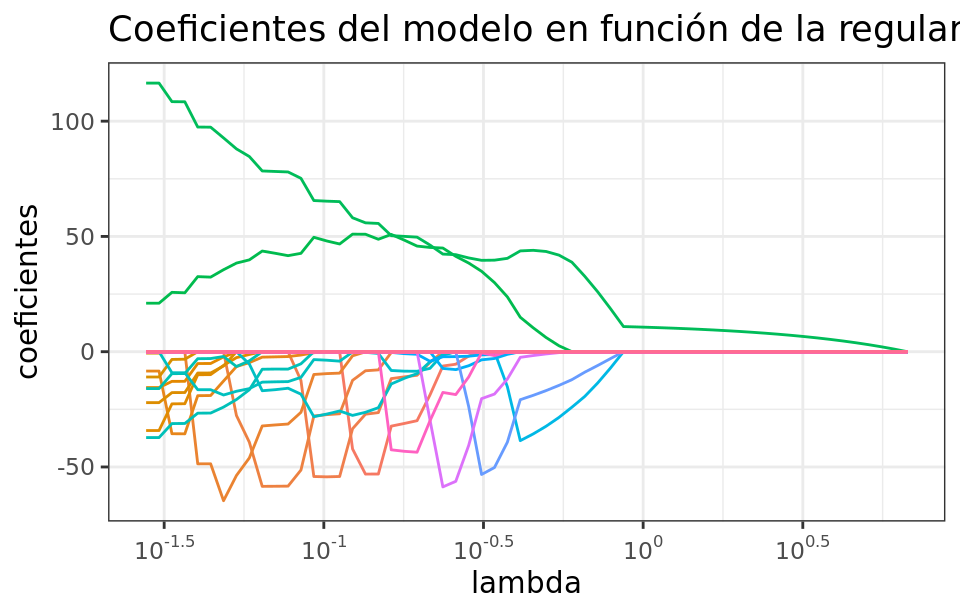

La regularización **Lasso** penaliza la suma de los valores absolutos de los coeficientes de regresión:

$$
||\beta||_1 = \sum_{j=1}^{p} |\beta_j|
$$

A esta penalización se le conoce como **L1**, y tiene el efecto de **forzar a que algunos coeficientes de los predictores se reduzcan exactamente a cero**. Esto significa que Lasso puede realizar **selección de variables**, excluyendo aquellos predictores menos relevantes.

Al igual que en Ridge, el grado de penalización está controlado por el hiperparámetro $\lambda$:
- Cuando $\lambda = 0$, la penalización es nula y el resultado es equivalente a un modelo lineal por mínimos cuadrados ordinarios (OLS).
- A medida que $\lambda$ aumenta, mayor es la penalización y más predictores quedan excluidos del modelo.

La función de costo de la regresión Lasso es:

$$
\sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \sum_{j=1}^{p} |\beta_j|
$$

$$
= \text{suma de residuos al cuadrado} + \lambda \sum_{j=1}^{p} |\beta_j|
$$


# **Comparación entre Ridge y Lasso**

La principal diferencia práctica entre **Lasso** y **Ridge** es su efecto en los coeficientes de regresión:

- **Lasso** tiende a reducir algunos coeficientes exactamente a **cero**, lo que **realiza selección de variables**.
- **Ridge**, en cambio, **nunca anula completamente** los coeficientes, sino que los reduce de manera proporcional.

### **¿Cuándo usar Ridge o Lasso?**
- **Lasso** es útil cuando se desea que solo los predictores más importantes permanezcan en el modelo, eliminando los menos influyentes.
- **Ridge** es preferible cuando **existen predictores altamente correlacionados**, ya que reduce la influencia de todos ellos de manera proporcional en lugar de eliminar algunos.

### **Inestabilidad en Lasso**
Cuando existen predictores fuertemente correlacionados, **Lasso selecciona uno de ellos** y excluye al resto. Sin embargo, esta selección puede ser **inestable**, variando con pequeños cambios en los datos de entrenamiento.

### **Elastic Net: la mejor combinación**
Para obtener un equilibrio entre la selección de variables de Lasso y la estabilidad de Ridge, se puede emplear la penalización **Elastic Net**, que combina ambas estrategias en un solo modelo.



# **Regresión Elastic Net**

Elastic Net combina las penalizaciones de **Lasso (L1)** y **Ridge (L2)** en un único modelo, mediante la siguiente regularización:

$$
\lambda \left( \alpha ||\beta||_1 + \frac{1}{2} (1 - \alpha) ||\beta||_2^2 \right)
$$

El grado en que influye cada una de las penalizaciones está controlado por el hiperparámetro $\alpha$, cuyo valor está en el intervalo $[0,1]$:
- Si $\alpha = 0$, el modelo se comporta como **Ridge**.
- Si $\alpha = 1$, el modelo se comporta como **Lasso**.
- Para valores intermedios de $\alpha$, se obtiene una combinación de ambas regularizaciones.

Elastic Net es útil cuando hay muchas variables correlacionadas, ya que la combinación de L1 y L2 proporciona un equilibrio entre selección de variables y estabilidad del modelo.

La función de costo de Elastic Net es:

$$
\frac{1}{2n} \sum_{i=1}^{n} \left( y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij} \right)^2 + \lambda \left( \alpha \sum_{j=1}^{p} |\beta_j| + \frac{1 - \alpha}{2} \sum_{j=1}^{p} \beta_j^2 \right)
$$



In [ ]:
import sklearn
# Cargar librerias

# Tratamiento de Datos

import pandas as pd
import numpy as np

#Graficos

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Preprocesamiento y Modelo

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

#Configuracion de nuestro visuales

plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')

#Ignorar las advertencias de paquetes y sus actualizaciones
import warnings
warnings.filterwarnings('ignore')

# Carga de Datos

Espectrofotometro = Instrumento capaz de detectar la absorbancia que tiene un material a diferentes tipos de luz

La empresa necesita comprobar que margen de error tiene respecto al analisis efectuado. Entonces, para ello se mide el espectro de absorbancia de 100 longitudes distintas en 215 muestras de carne. Entonces vamos a predecir el contenido de grasa apartir de los valores dados por el espectrofotometro.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
datos = pd.read_csv('/content/drive/MyDrive/Curso Estadistica con Python/meatspec.csv')

datos = datos.drop(columns = datos.columns[0])

datos.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V92,V93,V94,V95,V96,V97,V98,V99,V100,fat
0,2.61776,2.61814,2.61859,2.61912,2.61981,2.62071,2.62186,2.62334,2.62511,2.62722,...,2.98145,2.96072,2.94013,2.91978,2.89966,2.87964,2.85960,2.83940,2.81920,22.5
1,2.83454,2.83871,2.84283,2.84705,2.85138,2.85587,2.86060,2.86566,2.87093,2.87661,...,3.29186,3.27921,3.26655,3.25369,3.24045,3.22659,3.21181,3.19600,3.17942,40.1
2,2.58284,2.58458,2.58629,2.58808,2.58996,2.59192,2.59401,2.59627,2.59873,2.60131,...,2.68951,2.67009,2.65112,2.63262,2.61461,2.59718,2.58034,2.56404,2.54816,8.4
3,2.82286,2.82460,2.82630,2.82814,2.83001,2.83192,2.83392,2.83606,2.83842,2.84097,...,2.97367,2.94951,2.92576,2.90251,2.87988,2.85794,2.83672,2.81617,2.79622,5.9
4,2.78813,2.78989,2.79167,2.79350,2.79538,2.79746,2.79984,2.80254,2.80553,2.80890,...,3.30025,3.27907,3.25831,3.23784,3.21765,3.19766,3.17770,3.15770,3.13753,25.5


# Relacion entre variables

El primer paso a la hora de establecer un modelo lineal es estudiar la relacion que existen entre las variables. Esta informacion es critica a la hora de identificar cuales pueden ser los mejores predictores para el modelo e inclusive detectar la colinealidad entre predictores.

In [ ]:
# Correlacion entre columnas numericas

def matriz_correlacion(corr_mat):
  """ Funcion para Convertir una matriz de correlacion en formato numerica """
  corr_mat = corr_mat.stack().reset_index()
  corr_mat.columns = ['variable 1','variable 2','Correlacion']
  corr_mat = corr_mat.loc[corr_mat['variable 1'] != corr_mat['variable 2'], :]
  corr_mat['Valor Absoluto'] = np.abs(corr_mat['Correlacion'])
  corr_mat = corr_mat.sort_values('Valor Absoluto', ascending = False)

  return(corr_mat)

corr_matrix = datos.select_dtypes(include = ['float','int']).corr(method = 'pearson')
matriz_correlacion(corr_matrix).head(5)

,variable 1,variable 2,Correlacion,Valor Absoluto
1019,V11,V10,0.999996,0.999996
919,V10,V11,0.999996,0.999996
1121,V12,V11,0.999996,0.999996
1021,V11,V12,0.999996,0.999996
917,V10,V9,0.999996,0.999996


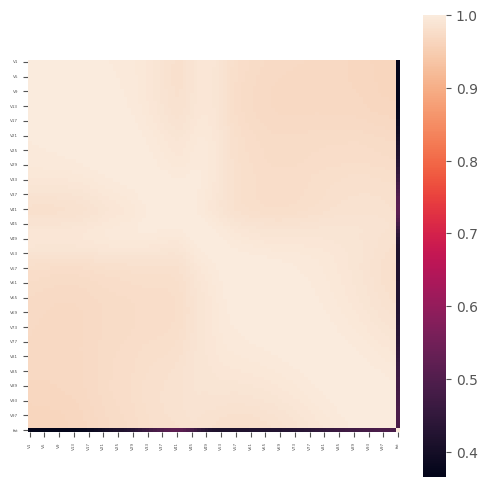

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,6))

sns.heatmap(
    corr_matrix,
    square = True,
    ax = ax)

ax.tick_params(labelsize = 3)

Muchas de las variables estan altamente correlacionadas (correlacion absoluta superior al 0.9), lo que supone un problema a la hora de emplear modelo de regresion lineal

# Modelos

Se van ajustar los modelos con y sin regularizacion, con  el objetivo de identificar cual de ellos es capaz de predecir mejor el contenido de grasa de la carne en funcion de la señales registradas por el espetrofotometro

In [ ]:
# Division de los datos

X = datos.drop(columns = 'fat')
y = datos['fat']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1,1),
    test_size = 0.2,
    random_state = 1234,
    shuffle = True)

# Minimos Cuadrados (OLS)

43 = test
172 = train

Y = B0 + b1x1 + b2x + .... + e

y = La variable dependiente
Xi = son las variables independientes
bi = son los coeficientes del modelo para cada variable
e = el error del modelo



In [ ]:
# Crear y entrenar el modelo

modelo = LinearRegression()
modelo.fit(X = X_train, y = y_train)

LinearRegression()

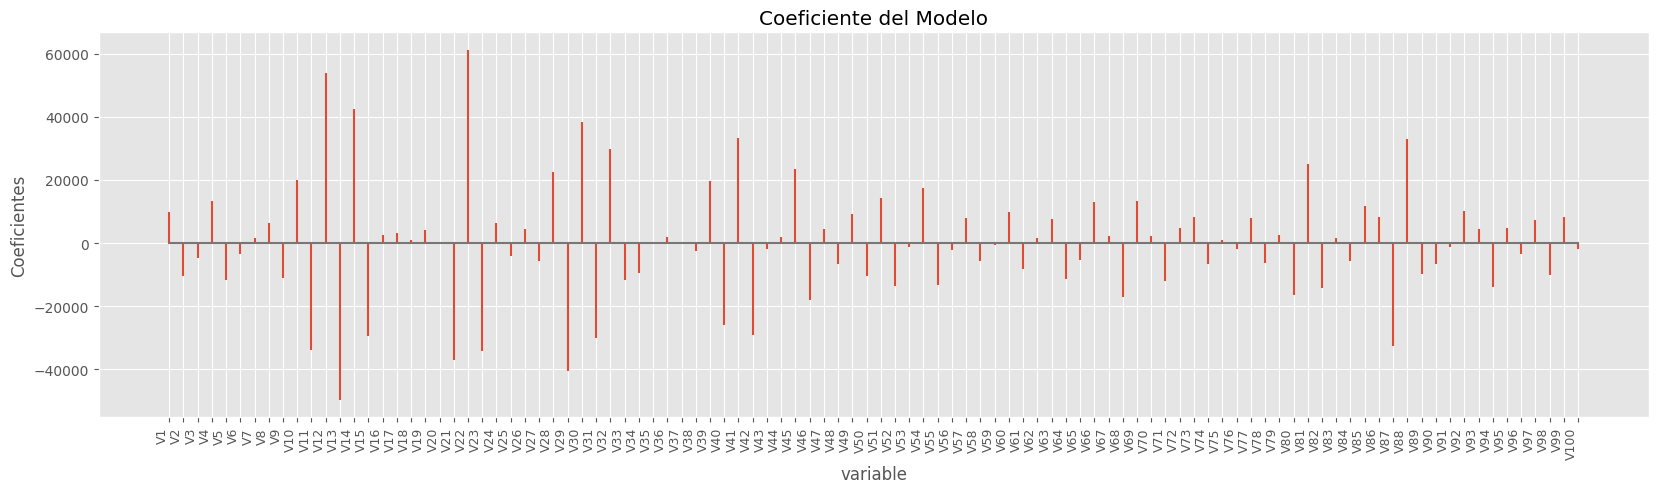

In [ ]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame(
    {'predictor':X_train.columns,
     'coef': modelo.coef_.flatten()})

fig, ax = plt.subplots(figsize =(20,5))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation = 90, ha = 'right', size = 9)
ax.set_ylabel('Coeficientes')
ax.set_xlabel('variable')
ax.set_title('Coeficiente del Modelo')
plt.show()

In [ ]:
# Predicciones del test

predicciones = modelo.predict(X= X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([38.09036706, 55.83225901, 50.95683507,  9.07912513, 17.94818191,
        6.60852856, 27.90226156,  9.0756674 , 15.24964032, 16.77073071])

In [ ]:
from sklearn.metrics import r2_score

r2_ols = r2_score(
    y_true  = y_test,
    y_pred = predicciones)

print(f'El coeficiente determinacion del test es: {r2_ols}')

El coeficiente determinacion del test es: 0.9484228015710516


# Ridge

In [ ]:
# Crear y entrenar el modelo (con busqueda de CV del valor optimo)

#Por defecto el metodo de RidgeCV utiliza para probar el modelo el MSE

modelo__ridge = RidgeCV(
    alphas = np.logspace(-10,2,200),
    fit_intercept= True,
    store_cv_values= True)

_ = modelo__ridge.fit(X=X_train, y = y_train)

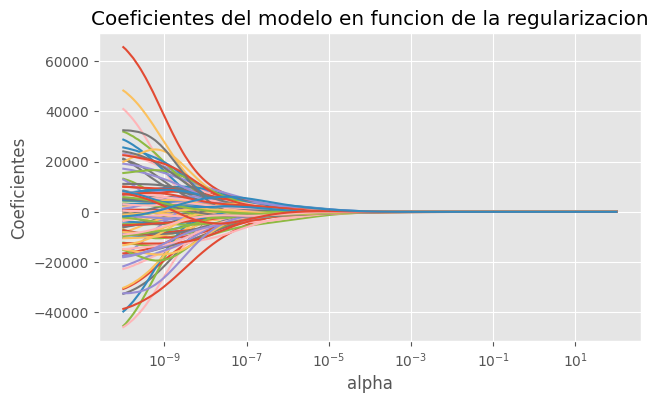

In [ ]:
# Evolucion de los coeficientes en funcion al alpha

alphas  = modelo__ridge.alphas

coefs =  []

for alpha in alphas:
  modelo_temp = Ridge(alpha = alpha, fit_intercept=False)
  modelo_temp.fit(X_train, y_train)
  coefs.append(modelo_temp.coef_.flatten())


fig, ax = plt.subplots(figsize =(7,4))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_title('Coeficientes del modelo en funcion de la regularizacion')
ax.set_xlabel('alpha')
ax.set_ylabel('Coeficientes')
plt.axis('tight')
plt.show()

A medida que aumenta el valor de alpha a la derecha, la regularizacion es mayor y el valor de los coeficientes se reduce

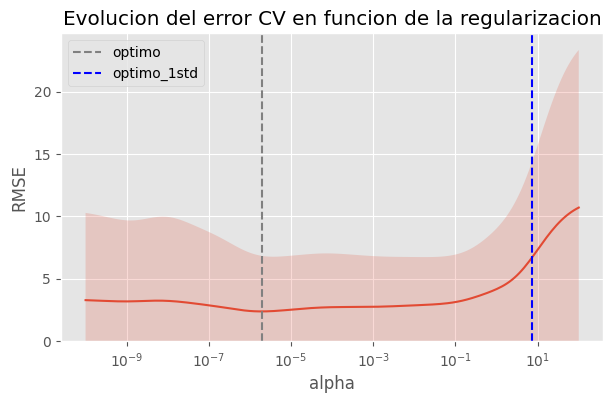

In [ ]:
# Evolucion del error en funcion de alpha
#modelo.cv_values_ almacenar el mse para cada de valor de alpha. Tiene dimensiones (n_samples, n_targets, n_alphas)

mse_cv = modelo__ridge.cv_values_.reshape((-1,200)).mean(axis = 0)
mse_sd = modelo__ridge.cv_values_.reshape((-1,200)).std(axis = 0)

# Se aplica la raiz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el optimo y el optimo + 1std

min_rmse = np.min(rmse_cv)
sd_min_rmse= rmse_sd[np.argmin(rmse_cv)]
min_rsme_1std = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo = modelo__ridge.alphas[np.argmin(rmse_cv)]
optimo_1std = modelo__ridge.alphas[rmse_cv == min_rsme_1std]

# Grafico del error +- 1 desviacion estandar

fig,ax = plt.subplots(figsize = (7,4))
ax.plot(modelo__ridge.alphas, rmse_cv)
ax.fill_between(
    modelo__ridge.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha = 0.2)

ax.axvline(x = optimo,
           c = 'gray',
           linestyle = '--',
           label = 'optimo')

ax.axvline(
    x = optimo_1std,
    c = 'blue',
    linestyle = '--',
    label = 'optimo_1std')

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolucion del error CV en funcion de la regularizacion')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()


In [ ]:
# Mejor parametro encontrado

print(f'Mejor valor de alpha encontrado: {modelo__ridge.alpha_}')

Mejor valor de alpha encontrado: 1.9116440753856998e-06


Text(0.5, 1.0, 'Coeficientes del modelo')

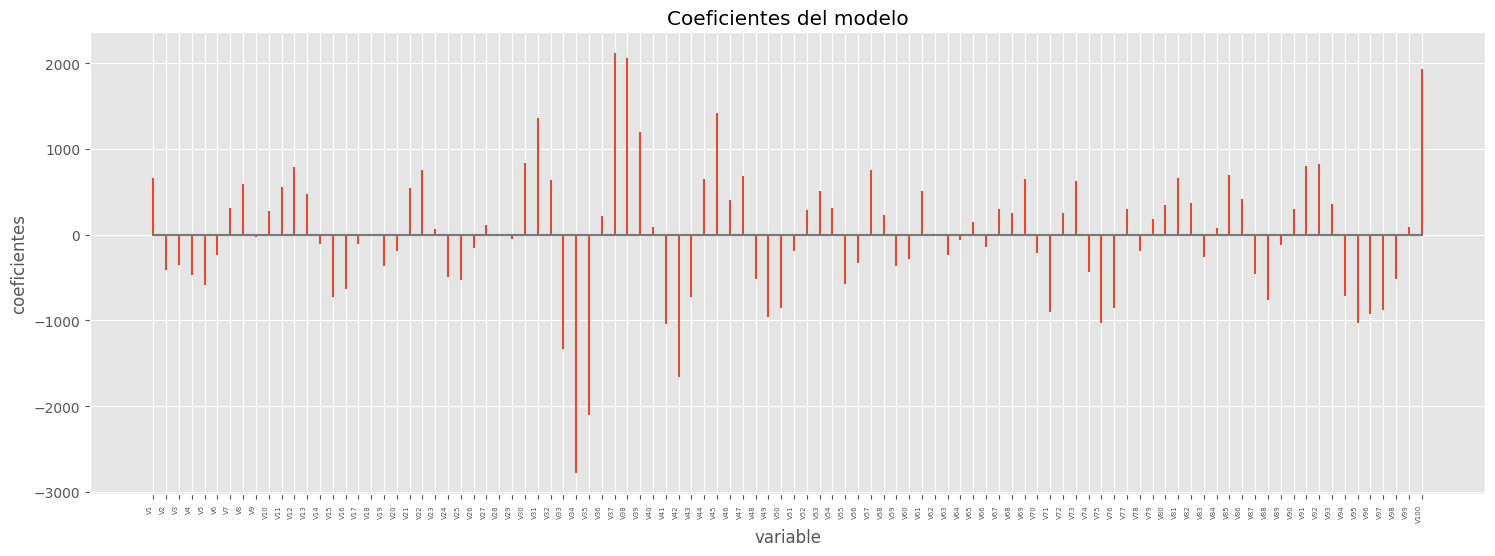

In [ ]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame(
    {'predictor':X_train.columns,
     'coef':modelo__ridge.coef_.flatten()})

fig, ax = plt.subplots(figsize = (18,6))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt = ' ')
plt.xticks(rotation = 90, ha = 'right' , size = 5)
ax.set_ylabel('coeficientes')
ax.set_xlabel('variable')
ax.set_title('Coeficientes del modelo')


En comparacion al modelo por minimos cuadrados ordinarios, con Ridge, el orden de la magnitud de los coeficientes es mucho menor

In [ ]:
# Predicciones del Test

predicciones = modelo__ridge.predict(X = X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([43.97300614, 42.71078025, 48.06807763,  9.72829761, 17.92944185,
        7.63246905, 27.93840205,  7.91156788, 14.84008585, 14.71032678])

In [ ]:
## Error del test del modelo

from sklearn.metrics import r2_score

r2_ridge = r2_score(
    y_true  = y_test,
    y_pred = predicciones)

print(f'El coeficiente determinacion del test es: {r2_ridge}')

mse_ridge = mean_squared_error(
    y_true = y_test,
    y_pred = predicciones)


rmse_ridge = np.sqrt(mse_ridge)

print(f'El error (rmse) del test es: {rmse_ridge}')

El coeficiente determinacion del test es: 0.9684552813205691
El error (rmse) del test es: 2.439711508743954


Las predicciones del modelo final se alejan en promedio 2.43 unidades del valor real

# Lasso

In [ ]:
# Crear y entrenar el modelo (con busqueda por CV del valor optimo de aplha)

# Por defecto el metodo RidgeCV utliza para probar el modelo el mean squared error

modelo = LassoCV(
    alphas = np.logspace(-10,3,200),
    cv= 10)

_ = modelo.fit(X= X_train, y =y_train)

Cuando se utiliza la regularizacion lasso es cuando los parametros se encuentran altamente correlacionados en ese caso, es util evaluar como se aproximan los coeficientes a Cero y esto sucede a medida que se incrementa el valor de alpha.

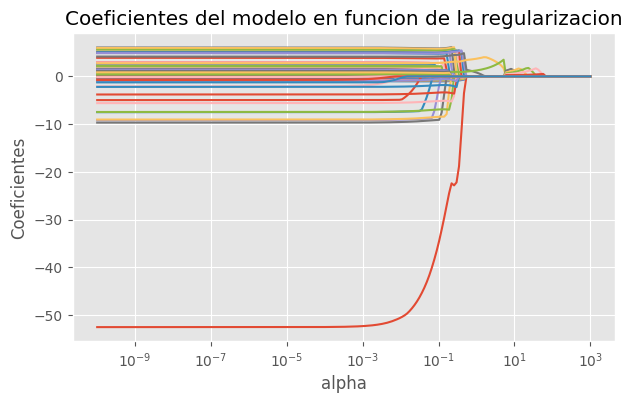

In [ ]:
# Evolucion de los coeficientes en funcion al alpha

alphas = modelo.alphas

coefs =[]

for alpha in alphas:
  modelo_temp = Lasso(alpha= alpha, fit_intercept= False)
  modelo_temp.fit(X_train, y_train)
  coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize = (7, 4))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_ylabel('Coeficientes')
ax.set_xlabel('alpha')
ax.set_title('Coeficientes del modelo en funcion de la regularizacion')
plt.axis('tight')
plt.show()

Podemos observar que a medida que aumenta el valor de alpha, la regularizacion es mayor y mas predictores quedan excluidos (porque el coeficientes es 0)

Text(0.5, 1.0, 'Predictores incluidos en funcion de la regularizacion')

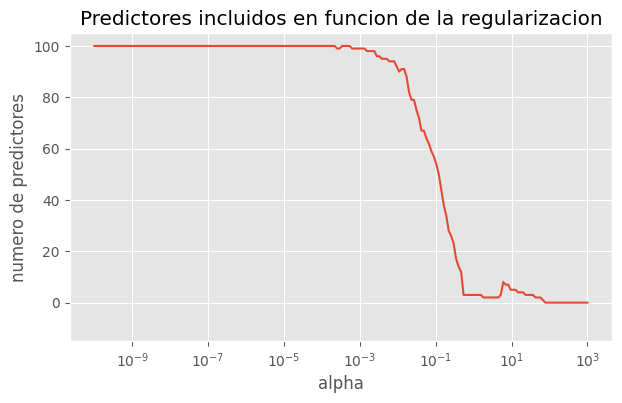

In [ ]:
# Numero de predictores incluidos (coeficientes != 0) en funcion de alpha

alphas = modelo.alphas_
n_predictores = []

for alpha in alphas:
  modelo_temp = Lasso(alpha = alpha, fit_intercept=False)
  modelo_temp.fit(X_train, y_train)
  coef_no_cero = np.sum(modelo_temp.coef_.flatten()!= 0)
  n_predictores.append(coef_no_cero)

fig,ax = plt.subplots(figsize = (7, 4))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-15, None])
ax.set_xlabel('alpha')
ax.set_ylabel('numero de predictores')
ax.set_title('Predictores incluidos en funcion de la regularizacion')

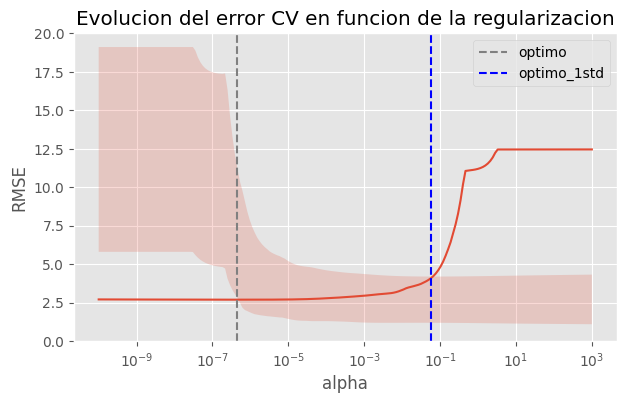

In [ ]:
# Evolucion del error en funcion de alpha
#modelo.mse_path_ almacenar el mse para cada de valor de alpha. Tiene dimensiones (n_samples, n_targets, n_alphas)

mse_cv = modelo.mse_path_.mean(axis = 1)
mse_sd = modelo.mse_path_.std(axis = 1)

# Se aplica la raiz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el optimo y el optimo + 1std

min_rmse = np.min(rmse_cv)
sd_min_rmse= rmse_sd[np.argmin(rmse_cv)]
min_rsme_1std = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1std = modelo.alphas_[rmse_cv == min_rsme_1std]

# Grafico del error +- 1 desviacion estandar

fig,ax = plt.subplots(figsize = (7,4))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha = 0.2)

ax.axvline(x = optimo,
           c = 'gray',
           linestyle = '--',
           label = 'optimo')

ax.axvline(
    x = optimo_1std,
    c = 'blue',
    linestyle = '--',
    label = 'optimo_1std')

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolucion del error CV en funcion de la regularizacion')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()
plt.show()

In [ ]:
# Mejor valor alpha

print(f'Mejor valor de alpha encontrado: {modelo.alpha_}')

Mejor valor de alpha encontrado: 4.552935074866957e-07


In [ ]:
# Se identifica el optimo y el optimo + 1std

min_rmse = np.min(rmse_cv)
sd_min_rmse= rmse_sd[np.argmin(rmse_cv)]
min_rsme_1std = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1std = modelo.alphas_[rmse_cv == min_rsme_1std]

print(f'Mejor valor de alpha encontrado: {optimo_1std}')

Mejor valor de alpha encontrado: [0.05672426]


In [ ]:
#Mejor Modelo alpha optimo + 1std

modelo = Lasso(alpha = 0.05672426)
modelo.fit(X_train, y_train)

Lasso(alpha=0.05672426)

In [ ]:
# Coeficientes

df_coeficientes = pd.DataFrame(
    {'predictor':X_train.columns,
     'coef':modelo.coef_.flatten()})


df_coeficientes[df_coeficientes.coef != 0]

,predictor,coef
7,V8,-5.024409
8,V9,-18.570337
9,V10,-16.171481
10,V11,-14.187749
11,V12,-12.165040
12,V13,-10.091060
13,V14,-7.931532
14,V15,-5.859009
15,V16,-3.984061
16,V17,-2.342876


De loaa 100 predictores disponibles, el modelo al final solo incluye 20

Text(0.5, 1.0, 'Coeficientes del modelo')

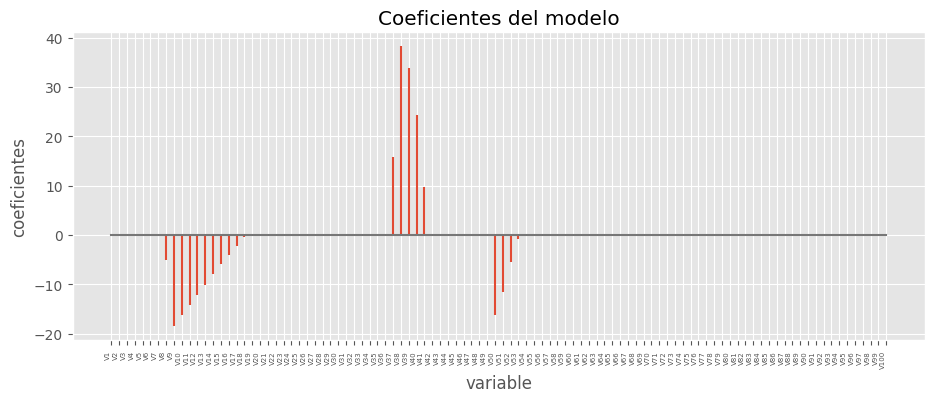

In [ ]:
fig, ax = plt.subplots(figsize = (11,4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt = ' ')
plt.xticks(rotation = 90, ha = 'right' , size = 5)
ax.set_ylabel('coeficientes')
ax.set_xlabel('variable')
ax.set_title('Coeficientes del modelo')

In [ ]:
# Predicciones del Test

predicciones = modelo.predict(X = X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([34.48551323, 53.87081169, 35.96192553, 12.27337237, 15.24023123,
        6.54352549, 24.48913688,  7.84738824, 13.62891777, 19.04542304])

In [ ]:
## Error del test del modelo

r2_lasso = r2_score(
    y_true  = y_test,
    y_pred = predicciones)

print(f'El coeficiente determinacion del test es: {r2_lasso}')

## Error del test del modelo

mse_lasso = mean_squared_error(
    y_true = y_test,
    y_pred = predicciones)

rmse_lasso = np.sqrt(mse_lasso)

print(f'El error (rmse) del test es: {rmse_lasso}')

El coeficiente determinacion del test es: 0.9218785652476743
El error (rmse) del test es: 3.839372509491673


# Elastic Net

In [ ]:
# Crear y entrenar el modelo (con busqueda por CV del valor optimo)
# Por defecto ElasticNetCV utiliza el mse

modelo = ElasticNetCV(
    l1_ratio = [0,0.1,0.5,0.7,0.9,0.95,0.99],
    alphas = np.logspace(-10,3, 200),
    cv=10)

_ = modelo.fit(X= X_train, y = y_train)


In [ ]:
# Evolucion del error en funcion de alpha y l1_ratio

## Error medio de las 10 particiones por cada alpha y l1 ratio

mean_error_cv = modelo.mse_path_.mean(axis = 2)

#Convertir los datos a un dataframe
df_resultados_cv = pd.DataFrame(
    data = mean_error_cv.flatten(),
    index = pd.MultiIndex.from_product(
        iterables= [modelo.l1_ratio, modelo.alphas_],
        names = ['l1_ratio','modelo.alphas']),
        columns = ['mse_cv'])

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv',ascending = True)
df_resultados_cv

,l1_ratio,modelo.alphas,mse_cv,rmse_cv
1341,0.99,6.150986e-07,7.246864,2.692000
1342,0.99,5.291979e-07,7.246881,2.692003
1340,0.99,7.149429e-07,7.246960,2.692018
1343,0.99,4.552935e-07,7.247004,2.692026
1339,0.99,8.309942e-07,7.247184,2.692059
...,...,...,...,...
630,0.70,1.096986e+01,155.309060,12.462306
632,0.70,8.119845e+00,155.309060,12.462306
633,0.70,6.985880e+00,155.309060,12.462306
634,0.70,6.010277e+00,155.309060,12.462306


Las predicciones del modelo final se alejan en promedio 2.78 unidades del valor real

Text(0, 0.5, 'rmse_cv')

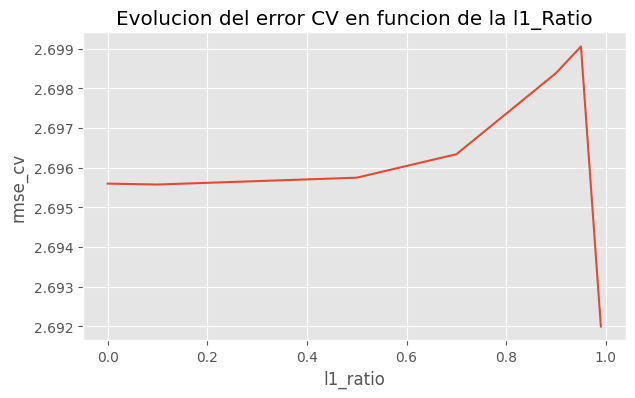

In [ ]:
# Mejor Valor Encontrado para cada l1_Ratio

fig,ax = plt.subplots(figsize = (7,4))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax =ax)
ax.set_title('Evolucion del error CV en funcion de la l1_Ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv')

In [ ]:
# Mejor valor alpha

print(f'Mejor valor de alpha encontrado: {modelo.alpha_}')
print(f'Mejor valor de l1_ratio_ encontrado: {modelo.l1_ratio_}')

Mejor valor de alpha encontrado: 6.150985788580504e-07
Mejor valor de l1_ratio_ encontrado: 0.99


In [ ]:
# Coeficientes

df_coeficientes = pd.DataFrame(
    {'predictor':X_train.columns,
     'coef':modelo.coef_.flatten()})

Text(0.5, 1.0, 'Coeficientes del modelo')

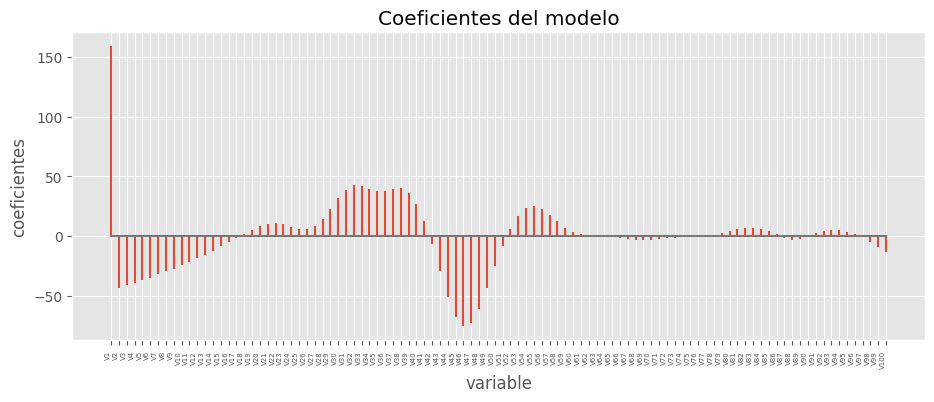

In [ ]:
fig, ax = plt.subplots(figsize = (11,4))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt = ' ')
plt.xticks(rotation = 90, ha = 'right' , size = 5)
ax.set_ylabel('coeficientes')
ax.set_xlabel('variable')
ax.set_title('Coeficientes del modelo')

In [ ]:
# Predicciones del Test

predicciones = modelo.predict(X = X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([22.65338709, 58.5825327 , 45.2102602 , 11.28483294, 16.15177428,
        5.6433578 , 26.1060508 , 10.25522346, 13.58406968, 22.68209276])

In [ ]:
## Error del test del modelo

## Error del test del modelo

r2_elatic_net = r2_score(
    y_true  = y_test,
    y_pred = predicciones)

print(f'El coeficiente determinacion del test es: {r2_elatic_net}')

mse_elastic = mean_squared_error(
    y_true = y_test,
    y_pred = predicciones)


rmse_elastic = np.sqrt(mse_elastic)

print(f'El error (rmse) del test es: {rmse_elastic}')

El coeficiente determinacion del test es: 0.8653440051495516
El error (rmse) del test es: 5.040666817212942


Las predicciones del modelo final se alejan en promedio 5.04 unidades del valor real.

#Comparacion

Text(0.5, 1.0, 'Comparacion de Modelos')

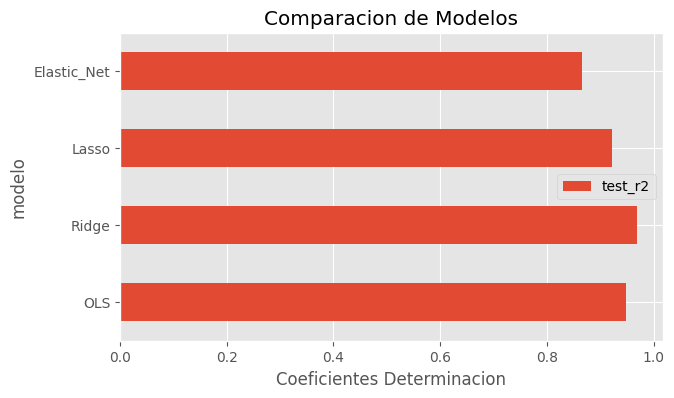

In [ ]:
df_comparacion = pd.DataFrame({
    'modelo':['OLS','Ridge','Lasso','Elastic_Net'],
    'test_r2':[r2_ols,r2_ridge,r2_lasso,r2_elatic_net]})

fig, ax = plt.subplots(figsize = (7,4))
df_comparacion.set_index('modelo').plot(kind = 'barh',ax = ax)
ax.set_xlabel('Coeficientes Determinacion')
ax.set_ylabel('modelo')
ax.set_title('Comparacion de Modelos')


In [ ]:
import joblib

joblib.dump(modelo__ridge, 'modelo_carnes.pkl')

['modelo_carnes.pkl']